# FAPE, FairGround Corpus Baseline Models
## Cross-Domain Fairness Evaluation

**Corpus:** FairGround, Simson et al. (2025)  
**Datasets:** 5 representative datasets across 5 domains  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  

| Domain | Dataset | Sensitive | n |
|--------|---------|-----------|---|
| Income | Adult | race | 32,560 |
| Criminal Justice | COMPAS 2-year | age (binned) | 6,172 |
| Credit | CreditCard | sex | 30,000 |
| Education | Law School (Lequy) | race | 18,692 |
| Healthcare | MEPS Panel 19 | race | 15,830 |

**Key findings (gradient boosting):**
- Education max_DP=0.329, largest racial gap
- Criminal Justice max_DP=0.258, age-based gap
- Credit max_DP=0.008, minimal sex disparity
- Gaps exceed 0.1 in three of the five domains (Education, Criminal Justice, and Income at 0.108); Healthcare (0.084) and Credit are below it

In [1]:
%matplotlib inline
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')
import logging
logging.disable(logging.CRITICAL)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
from sklearn.feature_selection import VarianceThreshold
import re

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)

MODEL_COLORS = {'LogisticRegression':'steelblue','RandomForest':'coral','GradientBoosting':'#5cb85c'}
DOMAIN_COLORS = {'Income':'steelblue','Criminal Justice':'#d9534f','Credit':'#5cb85c','Education':'#f0ad4e','Healthcare':'#9b59b6'}
DOMAINS = ['Income','Criminal Justice','Credit','Education','Healthcare']
print('Imports complete')

Imports complete


In [2]:
from baseline_fairground import SELECTED_DATASETS, prepare_dataset, fairness_metrics, MODELS
from fairground_loader import documented_feature_columns
from fairml_datasets import Datasets

print('Loading 5 FairGround datasets...')
datasets_obj = Datasets(include_large_datasets=False)
corpus = {}
for dataset in datasets_obj:
    ds_id = getattr(dataset, 'dataset_id', None)
    if ds_id not in SELECTED_DATASETS: continue
    dataset.load()
    df = dataset.to_pandas()
    target_col = dataset.get_target_column()
    feature_cols = documented_feature_columns(ds_id, df, target_col)
    corpus[ds_id] = {'X': df[feature_cols], 'y': df[target_col], 'df': df,
        'metadata': {'id': ds_id, 'n_samples': len(df), 'n_features': len(feature_cols),
                     'sensitive_columns': [], 'target_column': target_col, 'positive_rate': None},
        'sensitive_cols': []}
    print(f'   {ds_id}: {len(df):,} rows')

# Run all baselines
all_results = {}
MODELS_NB = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}
for ds_id, config in SELECTED_DATASETS.items():
    X, y, sensitive = prepare_dataset(corpus, ds_id, config)
    X_train, X_test, y_train, y_test, idx_tr, idx_te = train_test_split(
        X.values, y.values, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y.values)
    sens_test = sensitive.iloc[idx_te].reset_index(drop=True)
    if sens_test.nunique() > 10:
        sens_num = pd.to_numeric(sens_test, errors='coerce')
        if sens_num.notna().mean() > 0.8:
            sens_test = pd.cut(sens_num, bins=3, labels=['low','mid','high']).astype(str)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)
    ds_results = {}
    for name, model in MODELS_NB.items():
        if name == 'LogisticRegression':
            model.fit(X_tr_sc, y_train); y_pred = model.predict(X_te_sc); y_prob = model.predict_proba(X_te_sc)[:,1]
        else:
            model.fit(X_train, y_train); y_pred = model.predict(X_test); y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob); f1 = f1_score(y_test, y_pred)
        fm = fairness_metrics(y_test, y_pred, sens_test)
        dp_diffs = [abs(v['dp_diff']) for v in fm.values()]
        max_dp = max(dp_diffs) if dp_diffs else 0
        ds_results[name] = {'auc': auc, 'f1': f1, 'y_pred': y_pred, 'y_prob': y_prob,
                            'fairness': fm, 'max_dp': max_dp, 'y_test': y_test}
    all_results[ds_id] = {'config': config, 'results': ds_results, 'sensitive': sens_test}
    print(f'  {config["domain"]}: done')
print('All baselines complete')

Loading 5 FairGround datasets...
   adult: 32,560 rows
   compas_2_years: 6,172 rows
   creditcard: 30,000 rows
   law_school_lequy: 18,692 rows


   meps_panel_19_fy2015: 15,830 rows


  Income: done


  Criminal Justice: done


  Credit: done


  Education: done


  Healthcare: done
All baselines complete


## 1. Model Comparison, AUC Across 5 Domains

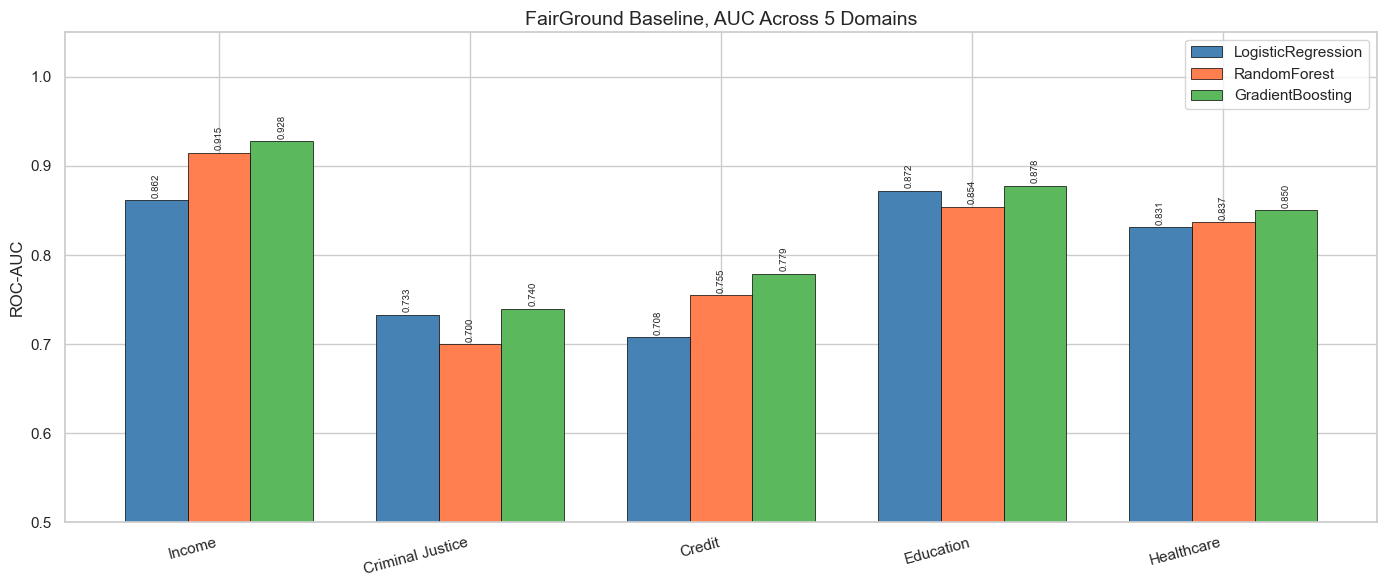

In [3]:
domains = [all_results[ds]['config']['domain'] for ds in SELECTED_DATASETS]
x = np.arange(len(domains)); width = 0.25

fig, ax = plt.subplots(figsize=(14,6))
for i, name in enumerate(MODELS_NB.keys()):
    aucs = [all_results[ds]['results'][name]['auc'] for ds in SELECTED_DATASETS]
    bars = ax.bar(x+i*width, aucs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', fontsize=7, rotation=90)
ax.set_xticks(x+width); ax.set_xticklabels(domains, rotation=15, ha='right')
ax.set_title('FairGround Baseline, AUC Across 5 Domains', fontsize=14)
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.5, 1.05); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Max Demographic Parity Gap by Domain

Education (0.329) and Criminal Justice (0.258) have largest fairness gaps. Credit minimal (0.008).

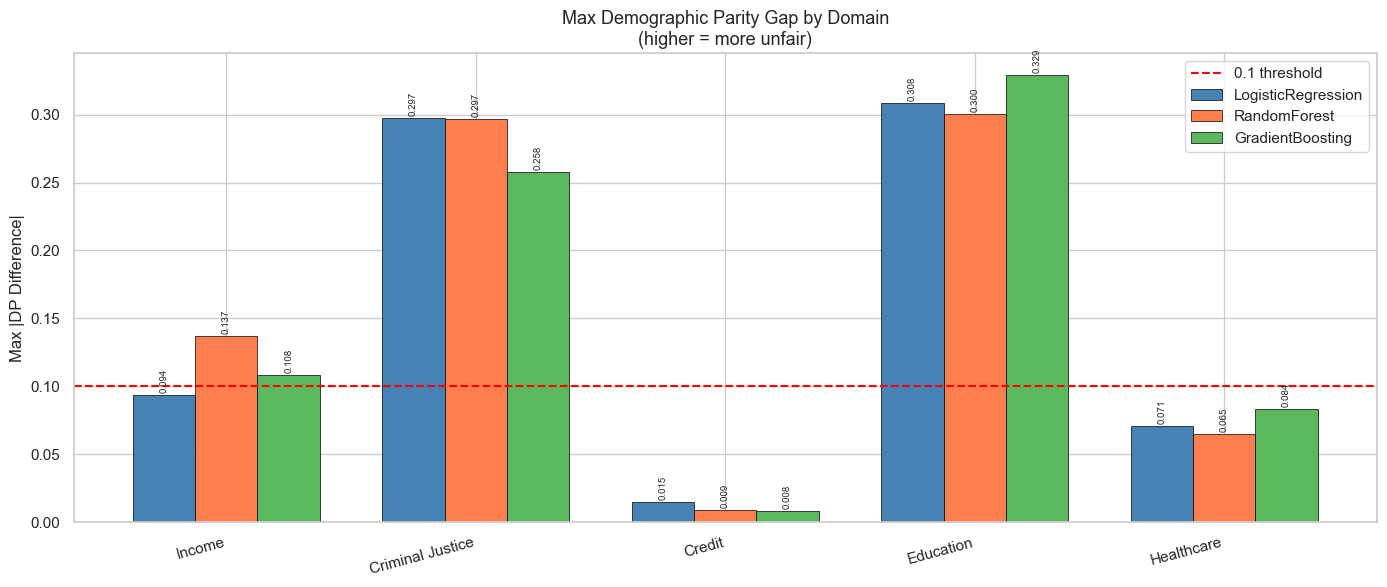

In [4]:
x = np.arange(len(domains)); width = 0.25

fig, ax = plt.subplots(figsize=(14,6))
for i, name in enumerate(MODELS_NB.keys()):
    dps = [all_results[ds]['results'][name]['max_dp'] for ds in SELECTED_DATASETS]
    bars = ax.bar(x+i*width, dps, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, dps):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.3f}', ha='center', fontsize=7, rotation=90)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5, label='0.1 threshold')
ax.set_xticks(x+width); ax.set_xticklabels(domains, rotation=15, ha='right')
ax.set_title('Max Demographic Parity Gap by Domain\n(higher = more unfair)', fontsize=13)
ax.set_ylabel('Max |DP Difference|'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_dp_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ROC Curves, Best Model Per Domain

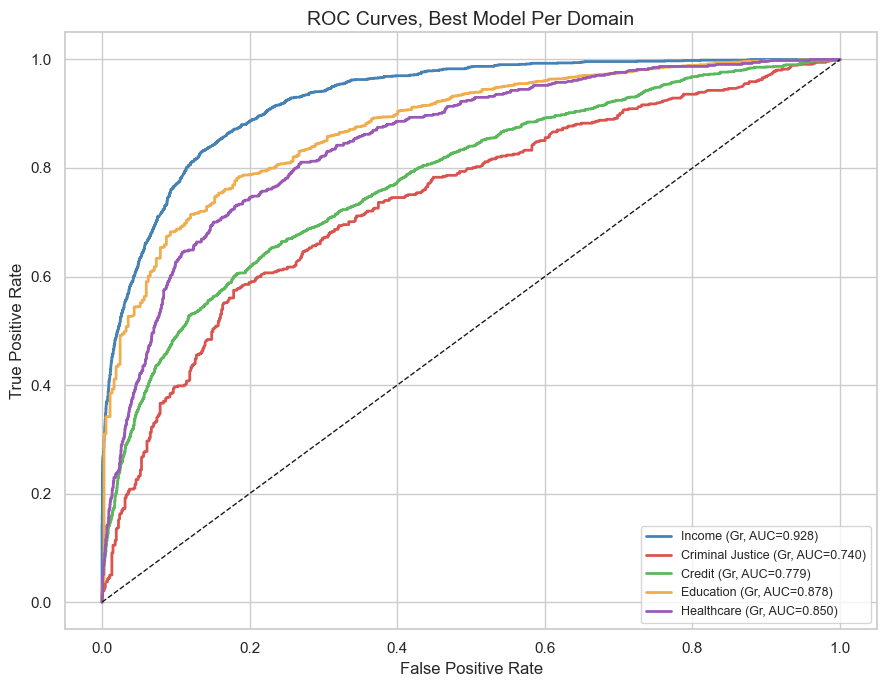

In [5]:
fig, ax = plt.subplots(figsize=(9,7))
for ds_id, data in all_results.items():
    best_name = max(data['results'].items(), key=lambda x: x[1]['auc'])[0]
    res = data['results'][best_name]
    fpr_c, tpr_c, _ = roc_curve(res['y_test'], res['y_prob'])
    domain = data['config']['domain']
    ax.plot(fpr_c, tpr_c, label=f'{domain} ({best_name[:2]}, AUC={res["auc"]:.3f})',
            color=DOMAIN_COLORS[domain], linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title('ROC Curves, Best Model Per Domain', fontsize=14)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Criminal Justice, Age-Based Fairness Gap

max_DP=0.258 across age groups (low/mid/high). Young defendants disadvantaged.

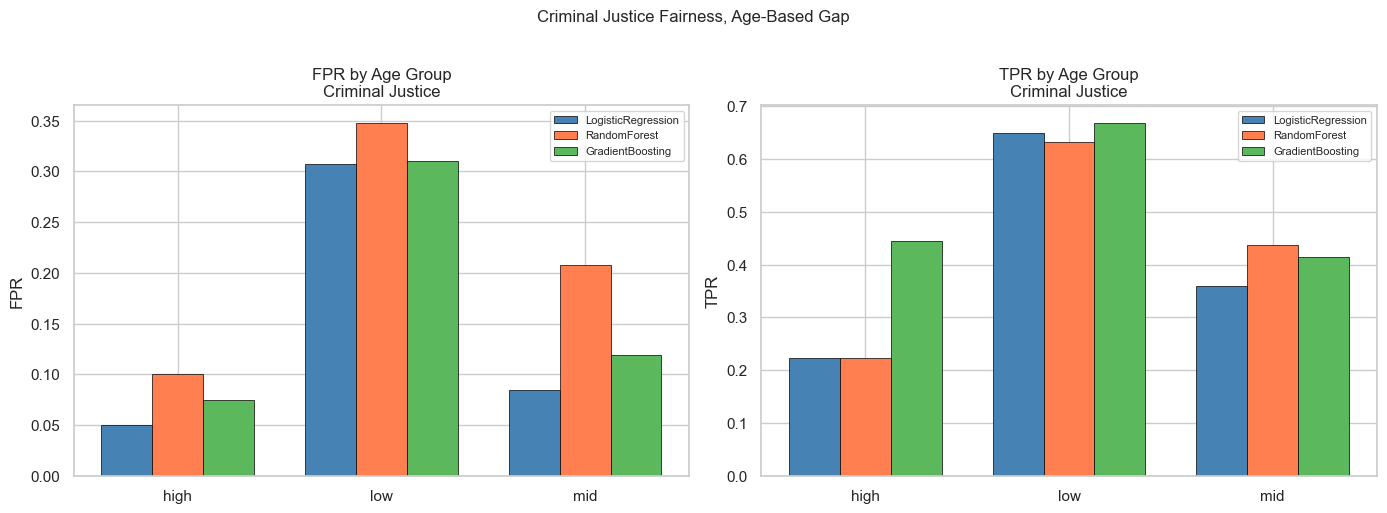

In [6]:
cj = all_results['compas_2_years']
cj_sens = cj['sensitive']
groups = sorted(cj_sens.dropna().unique())
x = np.arange(len(groups)); width = 0.25

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5))
for i, name in enumerate(MODELS_NB.keys()):
    res = cj['results'][name]
    fprs = [res['fairness'].get(g,{}).get('fpr',0) for g in groups]
    tprs = [res['fairness'].get(g,{}).get('tpr',0) for g in groups]
    ax1.bar(x+i*width, fprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    ax2.bar(x+i*width, tprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x+width); ax1.set_xticklabels(groups)
ax1.set_title('FPR by Age Group\nCriminal Justice', fontsize=12); ax1.set_ylabel('FPR'); ax1.legend(fontsize=8)
ax2.set_xticks(x+width); ax2.set_xticklabels(groups)
ax2.set_title('TPR by Age Group\nCriminal Justice', fontsize=12); ax2.set_ylabel('TPR'); ax2.legend(fontsize=8)
plt.suptitle('Criminal Justice Fairness, Age-Based Gap', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_criminal_justice_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Education, Race-Based Fairness Gap

max_DP=0.329, largest gap across all domains. Bar passage rate differs significantly by race.

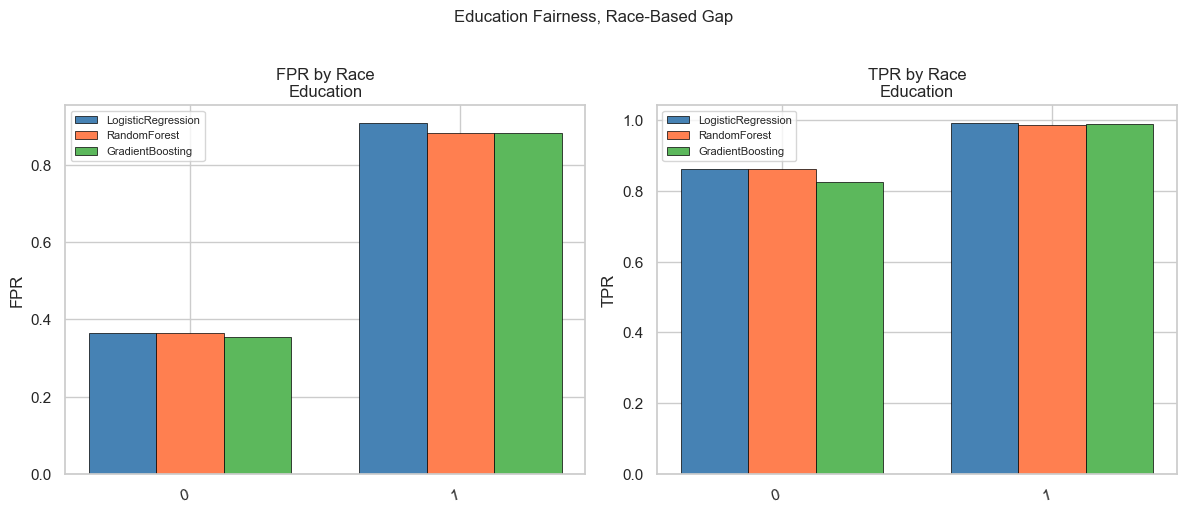

In [7]:
edu = all_results['law_school_lequy']
edu_sens = edu['sensitive']
groups = sorted(edu_sens.dropna().unique())
x = np.arange(len(groups)); width = 0.25

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))
for i, name in enumerate(MODELS_NB.keys()):
    res = edu['results'][name]
    fprs = [res['fairness'].get(g,{}).get('fpr',0) for g in groups]
    tprs = [res['fairness'].get(g,{}).get('tpr',0) for g in groups]
    ax1.bar(x+i*width, fprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    ax2.bar(x+i*width, tprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x+width); ax1.set_xticklabels(groups, rotation=15, ha='right')
ax1.set_title('FPR by Race\nEducation', fontsize=12); ax1.set_ylabel('FPR'); ax1.legend(fontsize=8)
ax2.set_xticks(x+width); ax2.set_xticklabels(groups, rotation=15, ha='right')
ax2.set_title('TPR by Race\nEducation', fontsize=12); ax2.set_ylabel('TPR'); ax2.legend(fontsize=8)
plt.suptitle('Education Fairness, Race-Based Gap', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_education_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Income, Race-Based Fairness Gap

max_DP=0.108 under gradient boosting (0.094 for logistic regression, 0.137 for random forest). Under gradient boosting the Amer-Indian-Eskimo, Black and Other groups are predicted above $50K less often than average (DP -0.108, -0.086 and -0.032), while Asian-Pac-Islander (+0.024) and White (+0.010) are predicted above it more often.

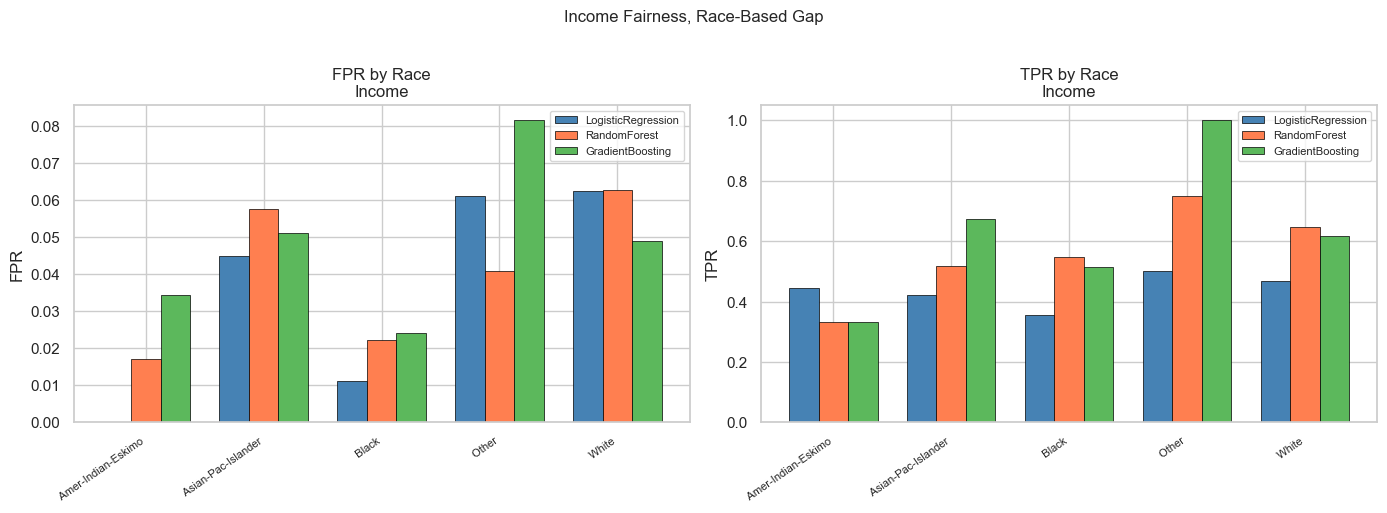

In [8]:
inc = all_results['adult']
inc_sens = inc['sensitive']
groups = sorted(inc_sens.dropna().unique())
x = np.arange(len(groups)); width = 0.25

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5))
for i, name in enumerate(MODELS_NB.keys()):
    res = inc['results'][name]
    fprs = [res['fairness'].get(g,{}).get('fpr',0) for g in groups]
    tprs = [res['fairness'].get(g,{}).get('tpr',0) for g in groups]
    ax1.bar(x+i*width, fprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    ax2.bar(x+i*width, tprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x+width); ax1.set_xticklabels(groups, rotation=35, ha='right', fontsize=8)
ax1.set_title('FPR by Race\nIncome', fontsize=12); ax1.set_ylabel('FPR'); ax1.legend(fontsize=8)
ax2.set_xticks(x+width); ax2.set_xticklabels(groups, rotation=35, ha='right', fontsize=8)
ax2.set_title('TPR by Race\nIncome', fontsize=12); ax2.set_ylabel('TPR'); ax2.legend(fontsize=8)
plt.suptitle('Income Fairness, Race-Based Gap', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_income_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Domain Fairness Heatmap

DP diff by domain and model, Education and Criminal Justice worst, Credit minimal.

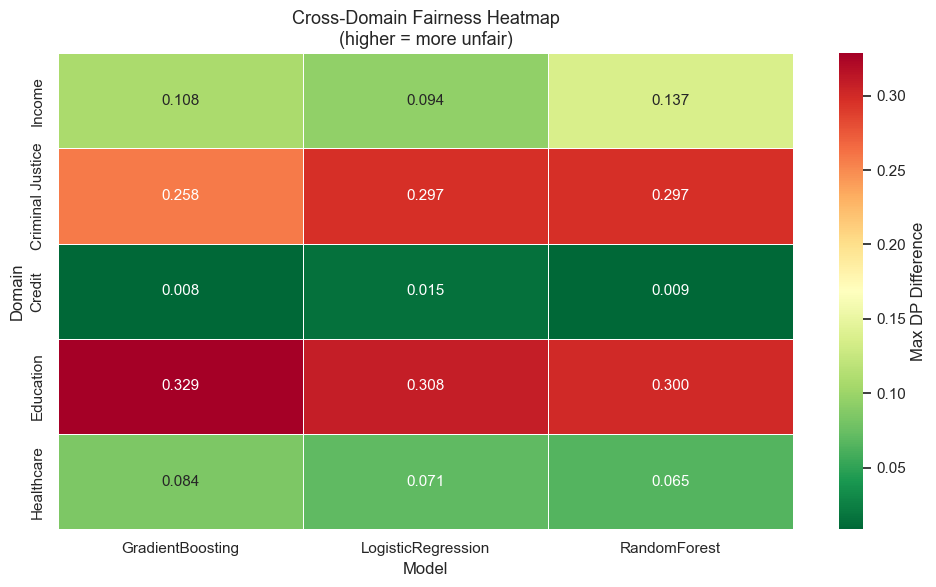

In [9]:
heat_data = []
for ds_id in SELECTED_DATASETS:
    domain = all_results[ds_id]['config']['domain']
    for name in MODELS_NB.keys():
        max_dp = all_results[ds_id]['results'][name]['max_dp']
        heat_data.append({'Domain': domain, 'Model': name, 'max_DP': max_dp})

heat_df = pd.DataFrame(heat_data).pivot(index='Domain', columns='Model', values='max_DP')
heat_df = heat_df.reindex(DOMAINS)

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Max DP Difference'})
ax.set_title('Cross-Domain Fairness Heatmap\n(higher = more unfair)', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_fairness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Positive Rate Disparity by Domain

Shows raw prediction rate differences across sensitive groups per domain.

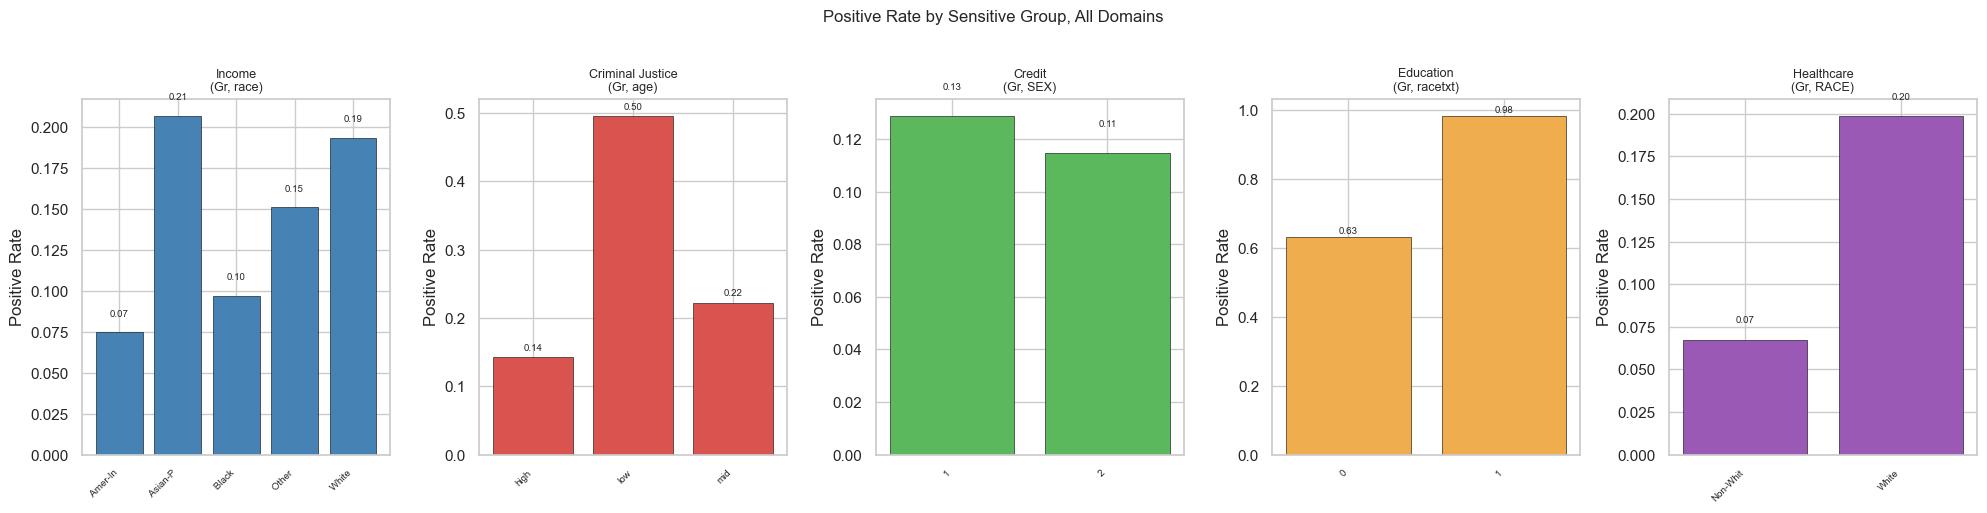

In [10]:
fig, axes = plt.subplots(1,5, figsize=(20,5))

for ax, (ds_id, data) in zip(axes, all_results.items()):
    domain = data['config']['domain']
    best_name = max(data['results'].items(), key=lambda x: x[1]['auc'])[0]
    res = data['results'][best_name]
    fm = res['fairness']
    groups = list(fm.keys())
    pos_rates = [fm[g]['pos_rate'] for g in groups]
    bars = ax.bar(range(len(groups)), pos_rates,
                  color=DOMAIN_COLORS[domain], edgecolor='black', linewidth=0.4)
    ax.set_title(f'{domain}\n({best_name[:2]}, {data["config"]["sensitive"]})', fontsize=9)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([str(g)[:8] for g in groups], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Positive Rate')
    for bar, val in zip(bars, pos_rates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.2f}',
                ha='center', fontsize=7)

plt.suptitle('Positive Rate by Sensitive Group, All Domains', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_positive_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Signed Demographic Parity, Direction of Bias

Bars to the right are groups predicted positive more often than the corpus rate, bars to the left less often. Education non-white (-32.9%) and Criminal Justice high-age (-25.8%) are the furthest below that rate.

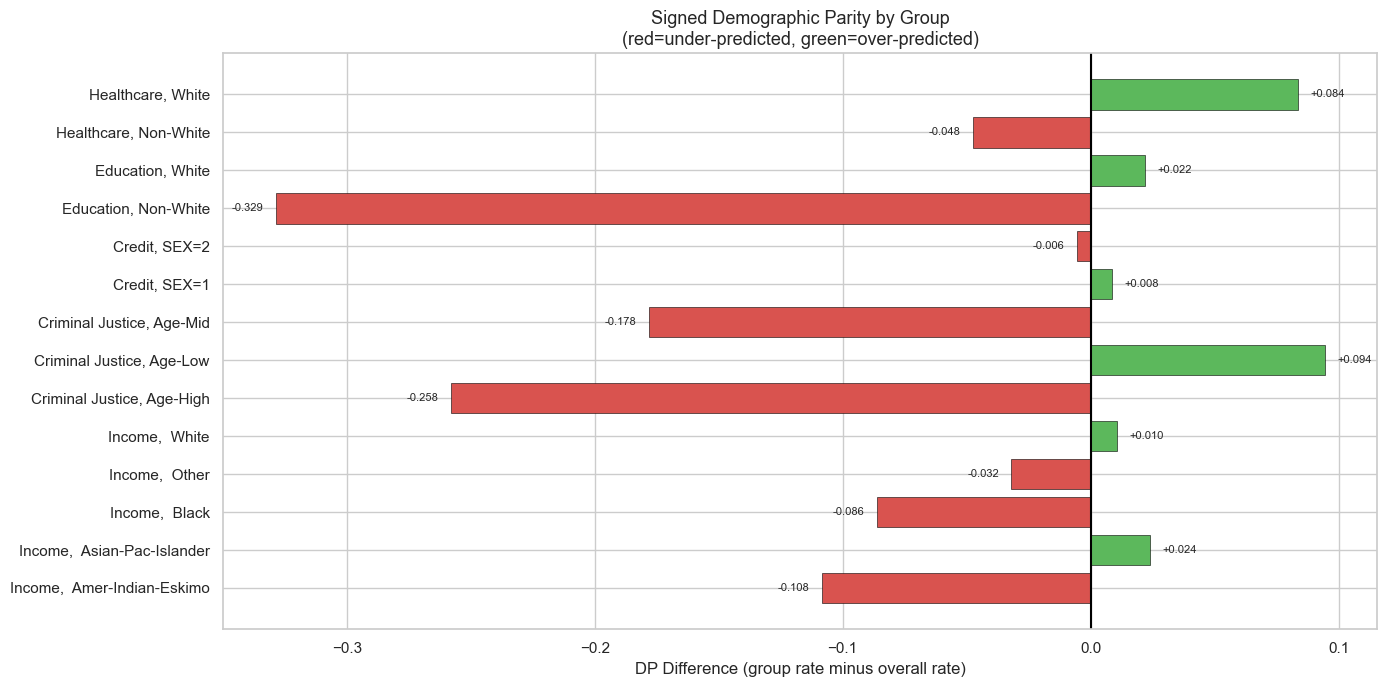

Most under-predicted: Education Non-White -0.329; Criminal Justice Age-High -0.258


In [11]:
# Signed DP per group for gradient boosting, read from all_results (groups with at least 30 test records)
def group_label(domain, grp):
    grp = str(grp)
    if domain == 'Criminal Justice':
        return f'Age-{grp.capitalize()}'
    if domain == 'Credit':
        return f'SEX={grp}'
    if domain == 'Education':
        return {'0': 'Non-White', '1': 'White'}.get(grp, grp)
    return grp

signed_dp_data = []
for ds_id in SELECTED_DATASETS:
    domain = all_results[ds_id]['config']['domain']
    fm = all_results[ds_id]['results']['GradientBoosting']['fairness']
    for grp in sorted(fm, key=str):
        signed_dp_data.append((domain, group_label(domain, grp), fm[grp]['dp_diff']))

sdp_df = pd.DataFrame(signed_dp_data, columns=['Domain','Group','DP'])
sdp_df['color'] = sdp_df['DP'].apply(lambda x: '#d9534f' if x < 0 else '#5cb85c')

fig, ax = plt.subplots(figsize=(14,7))
labels = [f'{r.Domain}, {r.Group}' for _, r in sdp_df.iterrows()]
bars = ax.barh(labels, sdp_df['DP'], color=sdp_df['color'],
               edgecolor='black', linewidth=0.4)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_title('Signed Demographic Parity by Group\n(red=under-predicted, green=over-predicted)',
             fontsize=13)
ax.set_xlabel('DP Difference (group rate minus overall rate)')
for bar, val in zip(bars, sdp_df['DP']):
    sign = '+' if val >= 0 else ''
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val+offset, bar.get_y()+bar.get_height()/2,
            f'{sign}{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_signed_dp.png', dpi=150, bbox_inches='tight')
plt.show()
lowest = sdp_df.nsmallest(2, 'DP')
print('Most under-predicted: ' + '; '.join(f'{r.Domain} {r.Group} {r.DP:+.3f}' for r in lowest.itertuples()))

## 10. AUC vs F1 Comparison, Class Imbalance Effects

Credit AUC=0.779 but F1=0.471; with a 22% positive rate F1 stays low. Education's F1 (0.953) is above its AUC (0.878) because 90% of its test labels are positive. Criminal Justice has the most balanced labels (46% positive), with AUC 0.740 and F1 0.645.

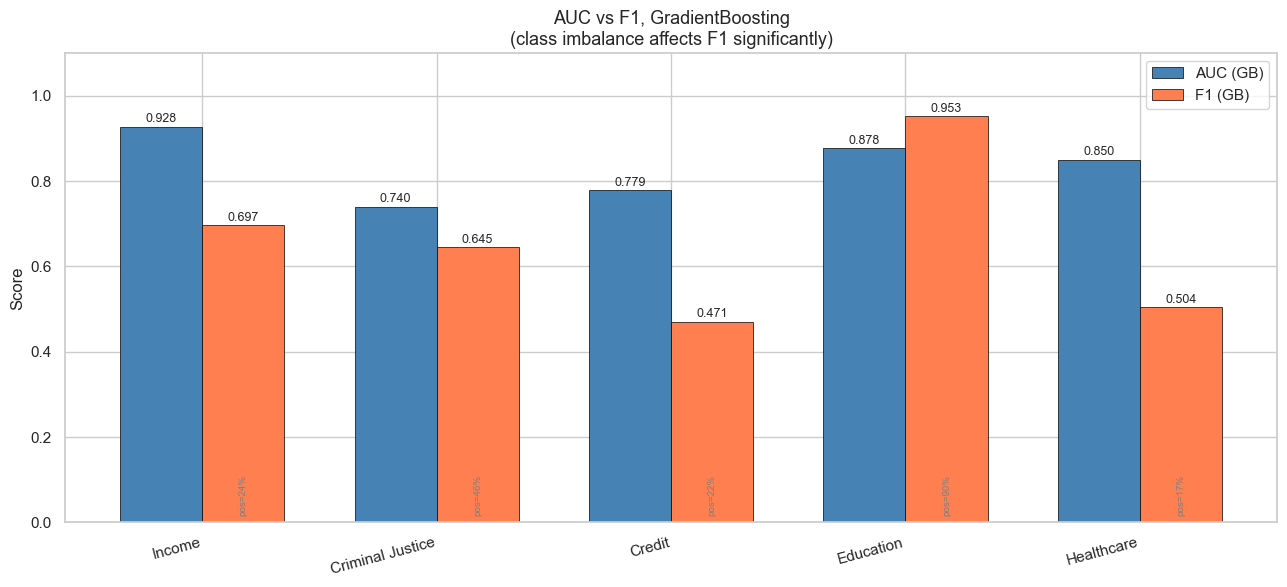

Income: AUC=0.928 F1=0.697 positive rate=24%
Criminal Justice: AUC=0.740 F1=0.645 positive rate=46%
Credit: AUC=0.779 F1=0.471 positive rate=22%
Education: AUC=0.878 F1=0.953 positive rate=90%
Healthcare: AUC=0.850 F1=0.504 positive rate=17%


In [12]:
order = list(SELECTED_DATASETS)
domains = [all_results[ds]['config']['domain'] for ds in order]
auc_gb = [all_results[ds]['results']['GradientBoosting']['auc'] for ds in order]
f1_gb = [all_results[ds]['results']['GradientBoosting']['f1'] for ds in order]
pos_rates = [all_results[ds]['results']['GradientBoosting']['y_test'].mean() for ds in order]

x = np.arange(len(domains)); width = 0.35
fig, ax = plt.subplots(figsize=(13,6))
bars1 = ax.bar(x-width/2, auc_gb, width, label='AUC (GB)',
               color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x+width/2, f1_gb, width, label='F1 (GB)',
               color='coral', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars1, auc_gb):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=9)
for bar, val, pr in zip(bars2, f1_gb, pos_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=9)
    ax.text(bar.get_x()+bar.get_width()/2, 0.02,
            f'pos={pr:.0%}', ha='center', fontsize=7, color='gray', rotation=90)
ax.set_xticks(x); ax.set_xticklabels(domains, rotation=15, ha='right')
ax.set_title('AUC vs F1, GradientBoosting\n(class imbalance affects F1 significantly)', fontsize=13)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_auc_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
for dom, a, f, pr in zip(domains, auc_gb, f1_gb, pos_rates):
    print(f'{dom}: AUC={a:.3f} F1={f:.3f} positive rate={pr:.0%}')

## 11. AUC vs Fairness Gap

Each point is one model on one dataset. A high AUC does not by itself mean a small demographic parity gap: law_school_lequy (Education) reaches an AUC of 0.878 under gradient boosting and has the largest gap, 0.329. The cell prints the correlation across all fifteen points.

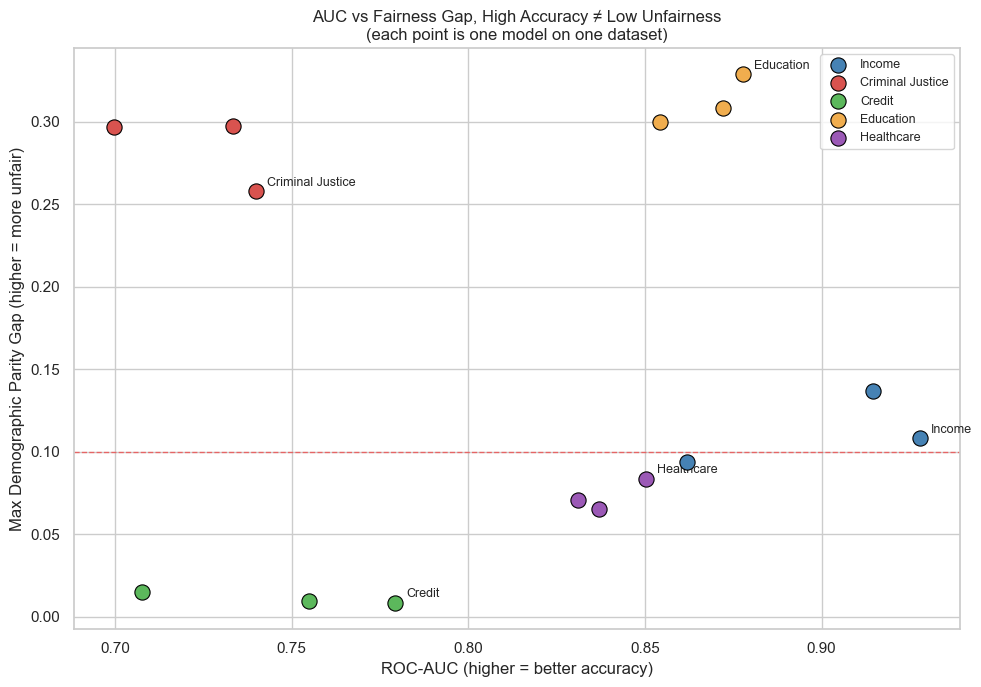

Largest DP gap: Education GB (AUC=0.878, DP=0.329)
Correlation between AUC and max DP across the 15 points: r=0.02


In [13]:
SHORT = {'LogisticRegression': 'LR', 'RandomForest': 'RF', 'GradientBoosting': 'GB'}
scatter_data = [(all_results[ds]['config']['domain'], SHORT[m], r['auc'], r['max_dp'])
                for ds in SELECTED_DATASETS for m, r in all_results[ds]['results'].items()]

sdf = pd.DataFrame(scatter_data, columns=['Domain','Model','AUC','DP'])

fig, ax = plt.subplots(figsize=(10,7))
for domain in DOMAINS:
    subset = sdf[sdf['Domain']==domain]
    ax.scatter(subset['AUC'], subset['DP'], s=120,
               color=DOMAIN_COLORS[domain], label=domain,
               edgecolor='black', linewidth=0.8, zorder=5)
    # Label GB point
    gb = subset[subset['Model']=='GB'].iloc[0]
    ax.annotate(domain, (gb['AUC'], gb['DP']),
                textcoords='offset points', xytext=(8,4), fontsize=9)
ax.set_xlabel('ROC-AUC (higher = better accuracy)', fontsize=12)
ax.set_ylabel('Max Demographic Parity Gap (higher = more unfair)', fontsize=12)
ax.set_title('AUC vs Fairness Gap, High Accuracy ≠ Low Unfairness\n'
             '(each point is one model on one dataset)',
             fontsize=12)
ax.legend(fontsize=9)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='DP=0.1 threshold')
plt.tight_layout()
plt.savefig('../figures/baseline/fairground_auc_vs_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
top = sdf.loc[sdf['DP'].idxmax()]
print(f"Largest DP gap: {top['Domain']} {top['Model']} (AUC={top['AUC']:.3f}, DP={top['DP']:.3f})")
print(f"Correlation between AUC and max DP across the {len(sdf)} points: r={sdf['AUC'].corr(sdf['DP']):.2f}")

## 12. Key Findings

**Cross-domain fairness baseline across 5 domains (max_DP under gradient boosting):**

- **Education** (max_DP=0.329): Largest racial gap, bar passage prediction favors white students
- **Criminal Justice** (max_DP=0.258): Age-based gap, young defendants face different FPR than older
- **Income** (max_DP=0.108): Race-based gap; Amer-Indian-Eskimo, Black and Other groups are under-predicted, Asian-Pac-Islander and White are not
- **Healthcare** (max_DP=0.084): Moderate racial gap in utilization prediction
- **Credit** (max_DP=0.008): Minimal sex disparity, the smallest gap of the five domains

**FAPE Stage 3 ThresholdOptimizer will target:**
- Reduce Education racial gap from 0.329 toward 0.05
- Reduce Criminal Justice age gap from 0.258 toward 0.05
- Maintain AUC within 5% of baseline across all domains